# Surface SW budget

By Ali Siddiqui

The purpose of this notebook is to show the closure of the surface shortwave budget in the Arctic region using the CSEM2-LENS output. I'm running it on the NCAR casper PBS cluster. 


In [1]:
import os
os.environ['PROJ_LIB'] = '/glade/u/home/asiddiqui/miniconda3/share/proj'

In [2]:
# remove temp dask worker files
!rm -f dask*

In [3]:
%load_ext watermark

import cf_xarray as cfxr
import dask_jobqueue
import distributed
import intake
import intake_esm
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import pint_xarray
from matplotlib.ticker import FormatStrFormatter
import xarray as xr
from cf_xarray.units import units
from matplotlib.patches import FancyBboxPatch# loads some UDUNITS definitions
import xeofs
import pop_tools
from tqdm import tqdm
import matplotlib.gridspec as gridspec


import xarray as xr
import seaborn as sns
from cartopy.crs import Robinson, PlateCarree

from xeofs.models import MCA, MCARotator

import cmocean
from matplotlib.patches import Polygon
%matplotlib inline

import warnings

import matplotlib.path                 as mpath
import cartopy.crs                     as ccrs
import cartopy.mpl.ticker              as ctk
import cartopy.feature as cfeature
import cartopy.mpl.patch as cpatch
import matplotlib as mpl

import shapely
import geopandas as gpd
import salem
import regionmask
from matplotlib.ticker import AutoMinorLocator


from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER


import intake
import matplotlib.pyplot as plt
import xarray as xr
from distributed import Client
from ncar_jobqueue import NCARCluster
import itertools

land_50m = cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                        edgecolor='face',
                                        facecolor=cfeature.COLORS['land'])

xr.set_options(keep_attrs=True)

%watermark -iv

dask_jobqueue: 0.8.2
pint_xarray  : 0.3
intake_esm   : 2023.6.14
seaborn      : 0.12.2
cartopy      : 0.21.1
sys          : 3.10.12 | packaged by conda-forge | (main, Jun 23 2023, 22:40:32) [GCC 12.3.0]
numpy        : 1.23.5
salem        : 0.3.10
intake       : 0.7.0
matplotlib   : 3.7.1
cmocean      : 3.0.3
distributed  : 2023.6.0
regionmask   : 0.12.1
geopandas    : 0.13.2
xeofs        : 1.0.3
pop_tools    : 2023.3.0
shapely      : 2.0.1
xarray       : 2023.6.0
cf_xarray    : 0.8.2



/glade/derecho/scratch/asiddiqui/tmp/ipykernel_49938/2222618421.py:44: DeprecationWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas still uses PyGEOS by default. However, starting with version 0.14, the default will switch to Shapely. To force to use Shapely 2.0 now, you can either uninstall PyGEOS or set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In the next release, GeoPandas will switch to using Shapely by default, even if PyGEOS is installed. If you only have PyGEOS installed to get speed-ups, this switch should be smooth. However, if you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [4]:
import matplotlib.pylab as pylab

pylab.rcParams.update({
  "text.usetex": True
})
plt.rcParams['font.family'] = 'Sans Serif'
plt.rcParams['font.serif'] = ['Helvetica']

In [5]:
cluster = dask_jobqueue.PBSCluster(
    cores=1,  # The number of cores you want
    memory='30GB',  # Amount of memory
    processes=1,  # How many processes
    queue='casper',  # The type of queue to utilize (/glade/u/apps/dav/opt/usr/bin/execcasper)
    local_directory='$TMPDIR',  # Use your local directory
    resource_spec='select=1:ncpus=1:mem=30GB',  # Specify resources
    project='NCGD0011',  # Input your project ID here
    walltime='08:00:00',  # Amount of wall time
    interface='ext',  # Interface to use
)

cluster.scale(400)

# Assign the cluster to our Client
client = Client(cluster)

/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/dask_jobqueue/core.py:255: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/u/home/asiddiqui/.conda/envs/pangeo_jun2023/lib/python3.10/site-packages/dask_jobqueue/core.py:274: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarnin

In [6]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/asiddiqui/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/asiddiqui/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.175:37837,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/asiddiqui/proxy/8787/status,Total threads: 0
Started: 1 minute ago,Total memory: 0 B


### Get the grid

In [7]:
import pop_tools
grid = pop_tools.get_grid('POP_gx1v7')
# grid_atm = pop_tools.get_grid('POP_tx0.1v3')
# grid_atm

In [8]:
DZT = np.zeros((60,384,320))

for k in range(60):
            DZT[k,:,:] = grid.dz[k]

### Using code available from Rodgers et al 2021 at https://github.com/kj-stein/CESM2-LE

In [9]:
VAR = ['fswdn','fswup','fswabs','SHF_QSW', 'fswthru','aice', 'siflswdtop', 'fswthrun', 'QSW_3D','siflswutop', 'sialb', 'siflswdbot'] #sithick : sea ice thickness sialb : sea ice albedo, aice : sea ice conc

scenarios=('HIST','SSP370')
members_cmip=('1001.001','1021.002','1041.003','1061.004','1081.005','1101.006','1121.007','1141.008','1161.009','1181.010',
              '1231.001','1231.002','1231.003','1231.004','1231.005','1231.006','1231.007','1231.008','1231.009','1231.010',
              '1251.001','1251.002','1251.003','1251.004','1251.005','1251.006','1251.007','1251.008','1251.009','1251.010',
              '1281.001','1281.002','1281.003','1281.004','1281.005','1281.006','1281.007','1281.008','1281.009','1281.010',
              '1301.001','1301.002','1301.003','1301.004','1301.005','1301.006','1301.007','1301.008','1301.009','1301.010')
members_smbb=('1011.001','1031.002','1051.003','1071.004','1091.005','1111.006','1131.007','1151.008','1171.009','1191.010',
              '1231.011','1231.012','1231.013','1231.014','1231.015','1231.016','1231.017','1231.018','1231.019','1231.020',
              '1251.011','1251.012','1251.013','1251.014','1251.015','1251.016','1251.017','1251.018','1251.019','1251.020',
              '1281.011','1281.012','1281.013','1281.014','1281.015','1281.016','1281.017','1281.018','1281.019','1281.020',
              '1301.011','1301.012','1301.013','1301.014','1301.015','1301.016','1301.017','1301.018','1301.019','1301.020')
members=members_cmip+members_smbb
ensembles = [ens for ens in range(len(members))]

In [10]:
exceptcv=['time','nlon','nlat','z_t','lat_aux_grid','transport_regions','moc_components','dz',*VAR]
def process_coords(ds, drop=True, except_coord_vars=exceptcv):
    """Preprocessor function to drop all non-dim coords, which slows down concatenation."""
    coord_vars = []
    for v in np.array(ds.coords) :
        if not v in except_coord_vars:
            coord_vars += [v]
    for v in np.array(ds.data_vars) :
        if not v in except_coord_vars:
            coord_vars += [v]
          
    if drop:
        return ds.drop(coord_vars)
    else:
        return ds.set_coords(coord_vars)

In [11]:
import glob

file_list=[]
for var in VAR :
    ens_files=[]
    for member in members :
        files=[]    
        for scenario in scenarios :
            comp,model,time='ice','cice.h','month_1'
            if var=='FSDS': comp,model,time='atm','cam.h0','month_1'
            if var=='SHF_QSW': comp,model,time='ocn','pop.h','month_1'
            if var=='QSW_3D': comp,model,time='ocn','pop.h','month_1'
            in_dir = '/glade/campaign/cgd/cesm/CESM2-LE/timeseries/'+comp+'/proc/tseries/'+time+'/'+var+'/'
            #'/proj/jedwards/archive/b.e21.B'+scenario+'*.f09_g17.LE2-'+member+'/'+comp+'/proc/tseries/'+time+'/'
            
            fn = 'b.e21.B'+scenario+'*.f09_g17.LE2-'+member+'.'+model+'.'+var+'.*.nc'
            files += glob.glob(in_dir+fn)
            files = sorted(files)
        ens_files.append(files)
    file_list.append(ens_files) 

In [12]:
for i in range(len(VAR)):
    print(i,VAR[i],len(file_list[i][:]))

0 fswdn 100
1 fswup 100
2 fswabs 100
3 SHF_QSW 100
4 fswthru 100
5 aice 100
6 siflswdtop 100
7 fswthrun 100
8 QSW_3D 100
9 siflswutop 100
10 sialb 100
11 siflswdbot 100


In [13]:
ds_0=xr.open_mfdataset(file_list[0],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_1=xr.open_mfdataset(file_list[1],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_2=xr.open_mfdataset(file_list[2],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_3=xr.open_mfdataset(file_list[3],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_4=xr.open_mfdataset(file_list[4],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_5=xr.open_mfdataset(file_list[5],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_6=xr.open_mfdataset(file_list[6],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_7=xr.open_mfdataset(file_list[7],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_8=xr.open_mfdataset(file_list[8],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_9=xr.open_mfdataset(file_list[9],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_10=xr.open_mfdataset(file_list[10],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)
ds_11=xr.open_mfdataset(file_list[11],chunks={'time':12},combine='nested',concat_dim=[[*ensembles],'time'],parallel='True',
                       preprocess=process_coords,decode_cf=True,decode_times=False)

Correcting for the time dimension

In [14]:
time = np.arange("1850-01", "2101-01", dtype="datetime64[M]")

In [15]:
ds_0['time'] = time
ds_1['time'] = time
ds_2['time'] = time
ds_3['time'] = time
ds_4['time'] = time
ds_5['time'] = time
ds_6['time'] = time
ds_7['time'] = time
ds_8['time'] = time
ds_9['time'] = time
ds_10['time'] = time
ds_11['time'] = time

/glade/derecho/scratch/asiddiqui/tmp/ipykernel_49938/2798615541.py:1: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_0['time'] = time
/glade/derecho/scratch/asiddiqui/tmp/ipykernel_49938/2798615541.py:1: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be sil

In [16]:
ds_0 = ds_0.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_1 = ds_1.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_2 = ds_2.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_3 = ds_3.rename({'concat_dim':'ensemble'})
ds_4 = ds_4.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_5 = ds_5.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_6 = ds_6.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_7 = ds_7.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_8 = ds_8.rename({'concat_dim':'ensemble'})
ds_9 = ds_9.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_10 = ds_10.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})
ds_11 = ds_11.rename({'concat_dim':'ensemble', 'nj':'nlat','ni':'nlon'})


In [17]:
ds_sw = xr.merge([ds_0['fswdn'], ds_1['fswup'], ds_2['fswabs'], ds_3['SHF_QSW'],
                  ds_4['fswthru'], ds_5['aice'], ds_6['siflswdtop'], ds_9['siflswutop'],
                 ds_10['sialb'], ds_11['siflswdbot']])
ds_sw

<xarray.Dataset>
Dimensions:     (time: 3012, ensemble: 100, nlat: 384, nlon: 320)
Coordinates:
  * time        (time) datetime64[ns] 1850-01-01 1850-02-01 ... 2100-12-01
  * ensemble    (ensemble) int64 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
Dimensions without coordinates: nlat, nlon
Data variables:
    fswdn       (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 384, 320), meta=np.ndarray>
    fswup       (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 384, 320), meta=np.ndarray>
    fswabs      (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 384, 320), meta=np.ndarray>
    SHF_QSW     (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 384, 320), meta=np.ndarray>
    fswthru     (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 384, 320), meta=np.ndarray>
    aice        (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 384, 320), meta=np.ndarray>
    siflswdtop  (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 384, 320), meta=np.ndarray>
    siflswutop  (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 384, 320), meta=np.ndarray>
    sialb       (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 384, 320), meta=np.ndarray>
    siflswdbot  (ensemble, time, nlat, nlon) float32 dask.array<chunksize=(1, 12, 384, 320), meta=np.ndarray>
Attributes:
    units:          W/m2
    long_name:      down solar flux
    cell_measures:  area: tarea
    cell_methods:   time: mean
    time_rep:       averaged

In [18]:
# ds_sw['aice'] = ds_sw['aice'].where(ds_sw['aice']<0.15)

In [19]:
ds_sw = ds_sw.where(grid.TLAT>0)
# ds_sw['aice'] = ds_sw['aice'].where(ds_sw['aice']>0.1)

In [20]:
# grid.TLONG.isel(nlat=360, nlon=200)

In [21]:
# grid.TLAT.isel(nlat=360, nlon=200)

In [22]:
# ds_sw.isel(ensemble=1, nlat=360, nlon=200).to_netcdf('data_files/shortwave_budget.nc')

In [23]:
# ds_sw.isel(ensemble=1, nlat=382, nlon=300).aice.plot()

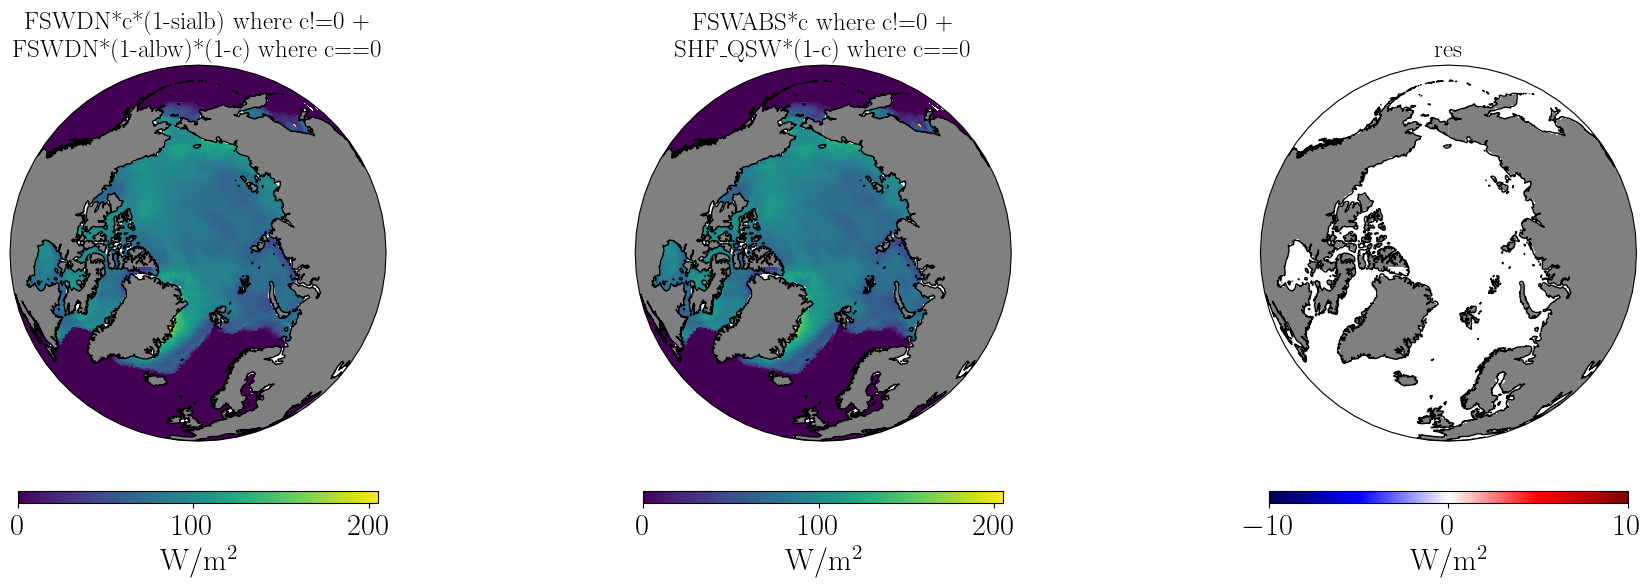

In [27]:
# Define projection
proj = ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)

# Define figure and axes
fig, ax = plt.subplots(ncols=3, nrows=1 ,subplot_kw={'projection': proj}, figsize=(20, 6))
ax = ax.flatten()



alb = (ds_sw.fswdn-ds_sw.fswabs)/ds_sw.fswdn
LHS = (1-alb)*ds_sw.fswdn.where(ds_sw.aice>0).fillna(0) #+ (1-0.06)*ds_sw.fswdn.where(ds_sw.aice==0).fillna(0)
RHS = ds_sw.fswabs #+ (ds_sw.SHF_QSW).where(ds_sw.aice==0).fillna(0)
res = LHS-RHS

# Define mappables for each subplot
mappables = [
    ax[0].pcolormesh(grid.TLONG, grid.TLAT, LHS.sel(time='2000-07', ensemble=10).squeeze(), transform=ccrs.PlateCarree()),
    ax[1].pcolormesh(grid.TLONG, grid.TLAT, RHS.sel(time='2000-07', ensemble=10).squeeze(), transform=ccrs.PlateCarree()),
    ax[2].pcolormesh(grid.TLONG, grid.TLAT, res.sel(time='2000-07', ensemble=10).squeeze(),vmin=-10, vmax=10, cmap='seismic',transform=ccrs.PlateCarree())
]

# Customize each subplot
for i in range(3):
    ax[i].coastlines()
    ax[i].add_feature(cfeature.LAND, facecolor='grey')

    # Add individual colorbar
    cbar = fig.colorbar(mappables[i], ax=ax[i], shrink=0.5, aspect=30, pad=0.1, orientation='horizontal')
    cbar.ax.set_xlabel('W/m$^2$', fontsize=22)
    cbar.ax.xaxis.set_label_position('bottom')
    cbar.ax.tick_params(labelsize=22)  

# Set titles
titles = ['FSWDN*c*(1-sialb) where c!=0 + \n FSWDN*(1-albw)*(1-c) where c==0 ', 'FSWABS*c where c!=0 + \n SHF_QSW*(1-c) where c==0', 'res']
for i in range(3):
    ax[i].set_title(titles[i], fontsize=18)

fig.tight_layout()
# fig.set_title('2050-07, ensemble=10')
# Save the figure
# plt.savefig('figs/surface_sw_budget_fswdn_siflswtop.png', format='png', bbox_inches='tight', dpi=300)


In [25]:
# # Define projection
# proj = ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)

# # Precompute LHS, RHS, and res for all months
# alb = (ds_sw.fswup/ds_sw.fswdn).fillna(0)
# LHS = ((1 - 0.07) * ds_sw.fswdn * (1 - ds_sw.aice)).where(ds_sw.aice == 0).fillna(0) + \
#       ((1 - alb) * ds_sw.fswdn * ds_sw.aice)
# RHS = (ds_sw.SHF_QSW * (1 - ds_sw.aice)).where(ds_sw.aice == 0).fillna(0) + \
#       (ds_sw.fswabs * ds_sw.aice)
# res = LHS - RHS

# # Create large figure
# fig, axs = plt.subplots(nrows=12, ncols=3, figsize=(18, 72), subplot_kw={'projection': proj})
# axs = axs.reshape(12, 3)

# # Titles for columns
# col_titles = [
#     r'FSWDN*c*(1-fswup/fswdn) where c$\neq$0 + FSWDN*(1-albw)*(1-c) where c=0',
#     r'FSWABS*c where c$\neq$0 + SHF_QSW*(1-c) where c=0',
#     'Residual (LHS - RHS)'
# ]

# for i, month in enumerate(range(1, 13)):
#     time_str = f'2050-{month:02d}'
#     lhs_month = LHS.sel(time=time_str, ensemble=10).squeeze()
#     rhs_month = RHS.sel(time=time_str, ensemble=10).squeeze()
#     res_month = res.sel(time=time_str, ensemble=10).squeeze()

#     data_list = [lhs_month, rhs_month, res_month]

#     for j in range(3):
#         ax = axs[i, j]
#         mappable = ax.pcolormesh(grid.TLONG, grid.TLAT, data_list[j],
#                                  transform=ccrs.PlateCarree(),
#                                  cmap='seismic' if j == 2 else None,
#                                  vmin=-10 if j == 2 else None,
#                                  vmax=10 if j == 2 else None)
#         ax.coastlines()
#         ax.add_feature(cfeature.LAND, facecolor='grey')

#         # Add colorbar
#         cbar = fig.colorbar(mappable, ax=ax, shrink=0.6, aspect=30, pad=0.01, orientation='horizontal')
#         cbar.ax.set_xlabel('W/m$^2$', fontsize=12)
#         cbar.ax.tick_params(labelsize=10)

#         # Set column titles on top row
#         if i == 0:
#             ax.set_title(col_titles[j], fontsize=14)

#         # Set row label (month)
#         if j == 0:
#             ax.text(-0.15, 0.5, time_str, va='center', ha='right',
#                     fontsize=18, transform=ax.transAxes, rotation=90)

# # Final adjustments
# fig.tight_layout(h_pad=1.5, w_pad=0.5)
# fig.subplots_adjust(top=0.98)
# # fig.suptitle('Surface SW Budget: 2050, Ensemble 10', fontsize=20, y=0.995)

# # Save the full figure
# plt.savefig('figs/surface_sw_budget_all_months_albedo_computed.png', dpi=300, bbox_inches='tight')

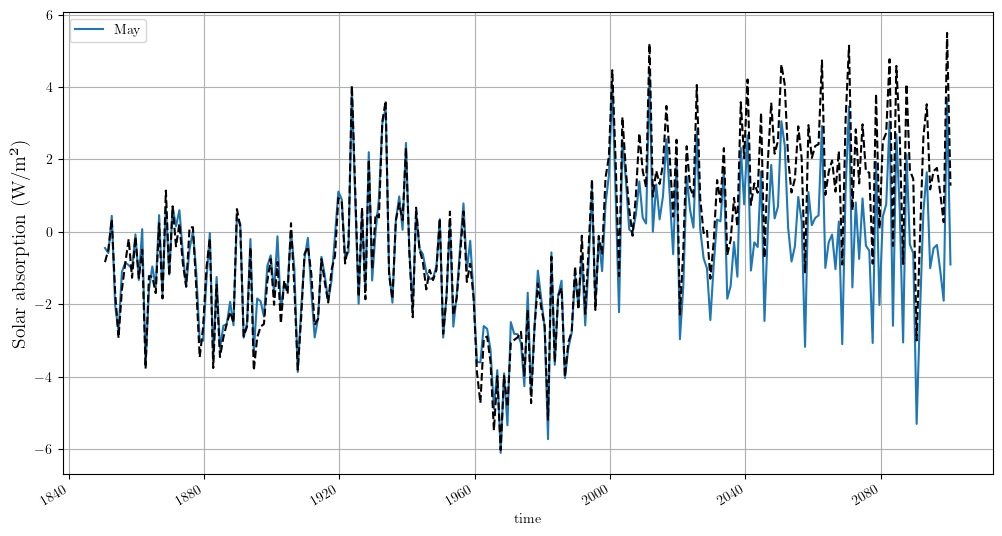

In [50]:
# Setup

alb = (ds_sw.fswdn-ds_sw.fswabs)/ds_sw.fswdn
LHS =  (1-alb)*(ds_sw.fswdn*ds_sw.aice).where(ds_sw.aice>0).fillna(0) + (1-0.06)*ds_sw.fswdn.where(ds_sw.aice==0).fillna(0) + ((1-0.06)*ds_sw.fswdn)*(1-ds_sw.aice).where(ds_sw.aice>0).fillna(0)
RHS =  ds_sw.fswabs*ds_sw.aice + (ds_sw.SHF_QSW).where(ds_sw.aice==0).fillna(0) + (ds_sw.SHF_QSW)*(1-ds_sw.aice).where(ds_sw.aice>0).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

colors1 = plt.cm.tab20.colors  # Get 20 distinct colors for up to 12 months
colors2 = plt.cm.tab10.colors  # Get 20 distinct colors for up to 12 months
month_names = ['May']#, 'Jun','Jul', 'Aug']

# Weight mask for the Arctic region
weights = grid.TAREA.where(grid.TLAT > 60).fillna(0)

# Plot for each month
for i in range(1):
    time_indices = (LHS.groupby('time.month').groups)[i+9]

    # Compute weighted mean for LHS and RHS for this month (across years)
    lhs_month = LHS.isel(time=time_indices).sel(ensemble=10).squeeze()
    rhs_month = RHS.isel(time=time_indices).sel(ensemble=10).squeeze()

    lhs_mean = lhs_month.weighted(weights).mean(('nlat', 'nlon'))
    rhs_mean = rhs_month.weighted(weights).mean(('nlat', 'nlon'))

    # remove the long term mean 
    lhs_anom = lhs_mean.groupby('time.month') - lhs_mean.sel(time=slice('1920-01', '1950-12')).groupby('time.month').mean('time')
    rhs_anom = rhs_mean.groupby('time.month') - rhs_mean.sel(time=slice('1920-01', '1950-12')).groupby('time.month').mean('time')
    
    # Plot both lines
    lhs_anom.plot(ax=ax, color=colors1[i], label=month_names[i])
    rhs_anom.plot(ax=ax, color='k', linestyle='--')

# Final touches
ax.set_ylabel('Solar absorption (W/m²)', fontsize=14)
#ax.set_title('Arctic (>66°N) Monthly Mean SW Absorption (LHS solid, RHS dashed)', fontsize=16)
ax.legend(ncol=6, fontsize=10)
ax.grid(True)


### Plotting all the months together now

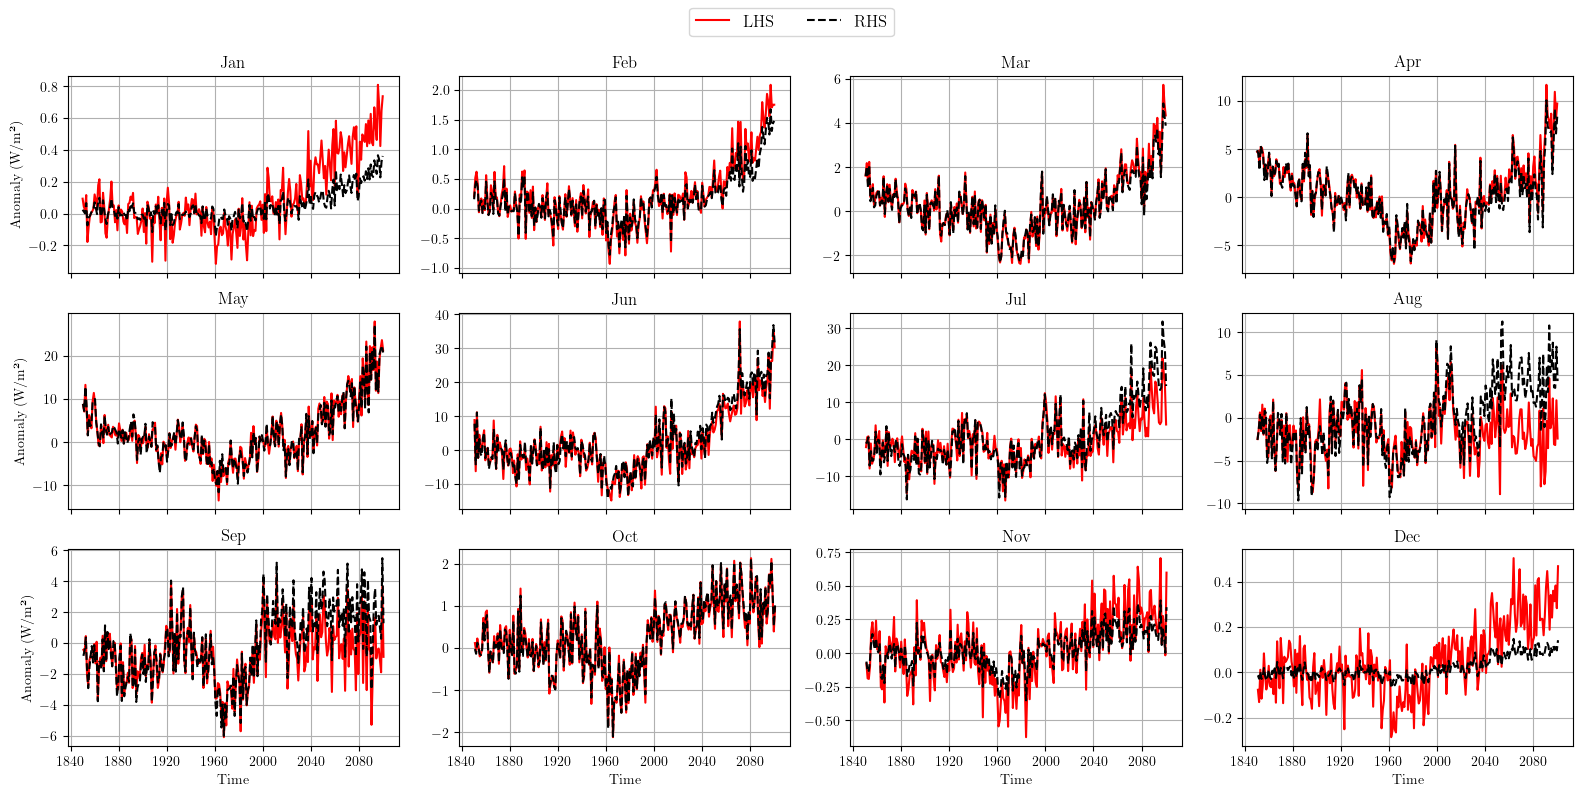

In [53]:
# Prepare albedo and solar absorption terms
alb = (ds_sw.fswdn - ds_sw.fswabs) / ds_sw.fswdn
LHS = (
    (1 - alb) * (ds_sw.fswdn * ds_sw.aice).where(ds_sw.aice > 0).fillna(0)
    + (1 - 0.06) * ds_sw.fswdn.where(ds_sw.aice == 0).fillna(0)
    + ((1 - 0.06) * ds_sw.fswdn) * (1 - ds_sw.aice).where(ds_sw.aice > 0).fillna(0)
)
RHS = (
    ds_sw.fswabs * ds_sw.aice
    + (ds_sw.SHF_QSW).where(ds_sw.aice == 0).fillna(0)
    + (ds_sw.SHF_QSW) * (1 - ds_sw.aice).where(ds_sw.aice > 0).fillna(0)
)

# Weight mask for Arctic region
weights = grid.TAREA.where(grid.TLAT > 60).fillna(0)

# Set up subplots for 12 months
fig, axs = plt.subplots(3, 4, figsize=(16, 8), sharex=True)
axs = axs.flatten()

colors1 = plt.cm.tab20.colors
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot each month's subplot
for i in range(12):
    ax = axs[i]
    time_indices = (LHS.groupby('time.month').groups)[i + 1]

    lhs_month = LHS.isel(time=time_indices).sel(ensemble=10).squeeze()
    rhs_month = RHS.isel(time=time_indices).sel(ensemble=10).squeeze()

    lhs_mean = lhs_month.weighted(weights).mean(('nlat', 'nlon'))
    rhs_mean = rhs_month.weighted(weights).mean(('nlat', 'nlon'))

    lhs_anom = lhs_mean.groupby('time.month') - lhs_mean.sel(time=slice('1920-01', '1950-12')).groupby('time.month').mean('time')
    rhs_anom = rhs_mean.groupby('time.month') - rhs_mean.sel(time=slice('1920-01', '1950-12')).groupby('time.month').mean('time')

    ax.plot(lhs_anom.time, lhs_anom, color='r', label='LHS')
    ax.plot(rhs_anom.time, rhs_anom, color='k', linestyle='--', label='RHS')

    ax.set_title(month_names[i])
    ax.grid(True)
    if i % 4 == 0:
        ax.set_ylabel('Anomaly (W/m²)')
    if i >= 8:
        ax.set_xlabel('Time')

# Adjust layout and legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=12)
# fig.suptitle('Monthly Arctic (>60°N) SW Absorption Anomalies (LHS solid, RHS dashed)', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('figs/surface_sw_budget_all_months.png', format='png', dpi=300, bbox_inches='tight')

### Conclusion

- FSWDN-FSWUP = FSWABS, and </br>
- siflswdtop - siflswutop  = FSWABS in the interior arctic </br>
- siflswutop/siflswdtop is approx fswup/fswdn and the diff with sialb for both is order 0.1, i.e. 10% error
    - FSWABS x aice = FSWDN x (1-sialb) x aice and not FSWABS x aice = FSWDN x (1-sialb x aice)
- sialb, FSWABS, FSWDN are grid cell averages

In [ ]:
with plt.rc_context({'text.usetex': False}):
    res.isel(time=(res.groupby('time.month').groups)[8]).sel(ensemble=10).squeeze().weighted(grid.TAREA).mean(('nlat','nlon')).plot()

### Figuring out the difference between siflswdtop and fswdn

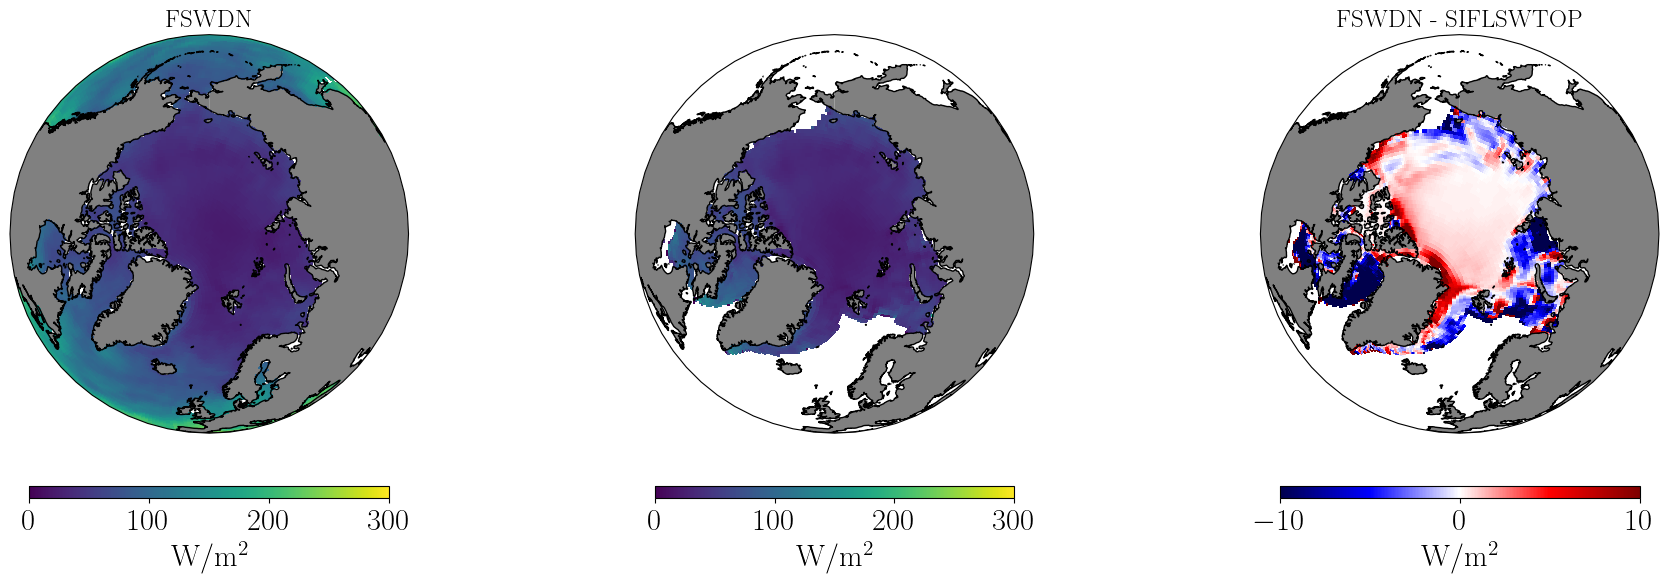

In [31]:
# Define projection
proj = ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)

# Define figure and axes
fig, ax = plt.subplots(ncols=3, nrows=1 ,subplot_kw={'projection': proj}, figsize=(20, 6))
ax = ax.flatten()

# Define mappables for each subplot
mappables = [
    ax[0].pcolormesh(grid.TLONG, grid.TLAT, ds_sw.fswdn.sel(time='1980-09', ensemble=10).squeeze(), vmin=0, vmax=300, transform=ccrs.PlateCarree()),
    ax[1].pcolormesh(grid.TLONG, grid.TLAT, ds_sw['siflswdtop'].sel(time='1980-09', ensemble=10).squeeze(), vmin=0, vmax=300, transform=ccrs.PlateCarree()),
    ax[2].pcolormesh(grid.TLONG, grid.TLAT, (ds_sw.fswdn-ds_sw['siflswdtop']).sel(time='1980-09', ensemble=10).squeeze(), 
                                                                                                     vmin=-10, vmax=10, cmap='seismic',transform=ccrs.PlateCarree())
]

# Customize each subplot
for i in range(3):
    ax[i].coastlines()
    ax[i].add_feature(cfeature.LAND, facecolor='grey')

    # Add individual colorbar
    cbar = fig.colorbar(mappables[i], ax=ax[i], shrink=0.5, aspect=30, pad=0.1, orientation='horizontal')
    cbar.ax.set_xlabel('W/m$^2$', fontsize=22)
    cbar.ax.xaxis.set_label_position('bottom')
    cbar.ax.tick_params(labelsize=22)  

# Set titles
titles = ['FSWDN','', 'FSWDN - SIFLSWTOP']
for i in range(3):
    ax[i].set_title(titles[i], fontsize=18)

fig.tight_layout()
# Save the figure
# plt.savefig('figs/surface_sw_budget_fswdn_siflswtop.png', format='png', bbox_inches='tight', dpi=300)


### Figuring out the difference between QSW_3D and SHF_QSW

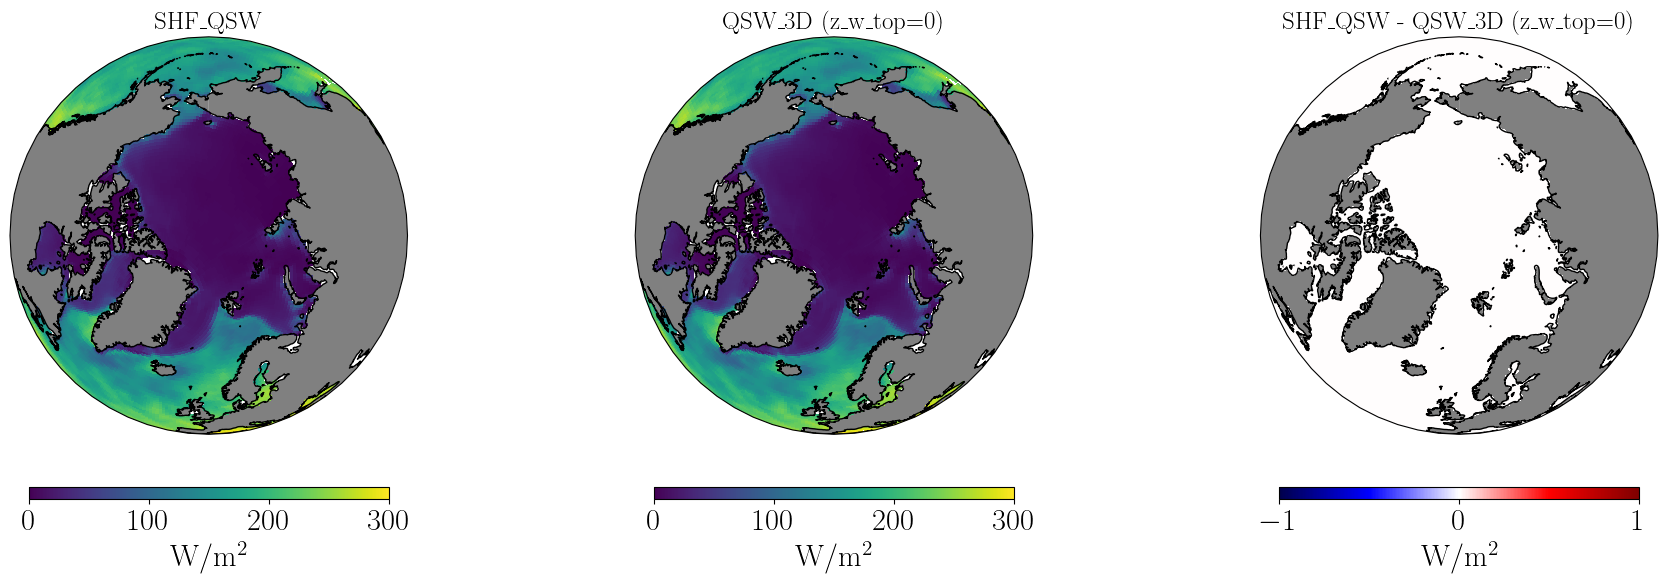

In [32]:
# Define projection
proj = ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)

# Define figure and axes
fig, ax = plt.subplots(ncols=3, nrows=1 ,subplot_kw={'projection': proj}, figsize=(20, 6))
ax = ax.flatten()

# Define mappables for each subplot
mappables = [
    ax[0].pcolormesh(grid.TLONG, grid.TLAT, ds_sw.SHF_QSW.sel(time='1980-05', ensemble=10).squeeze(), vmin=0, vmax=300, transform=ccrs.PlateCarree()),
    ax[1].pcolormesh(grid.TLONG, grid.TLAT, ds_8['QSW_3D'].sel(time='1980-05', ensemble=10, z_w_top=0).squeeze(), vmin=0, vmax=300, transform=ccrs.PlateCarree()),
    ax[2].pcolormesh(grid.TLONG, grid.TLAT, (ds_sw.SHF_QSW-ds_8['QSW_3D'].sel(z_w_top=0)).sel(time='1980-05', ensemble=10).squeeze(), 
                                                                                                     vmin=-1, vmax=1, cmap='seismic',transform=ccrs.PlateCarree())
]

# Customize each subplot
for i in range(3):
    ax[i].coastlines()
    ax[i].add_feature(cfeature.LAND, facecolor='grey')

    # Add individual colorbar
    cbar = fig.colorbar(mappables[i], ax=ax[i], shrink=0.5, aspect=30, pad=0.1, orientation='horizontal')
    cbar.ax.set_xlabel('W/m$^2$', fontsize=22)
    cbar.ax.xaxis.set_label_position('bottom')
    cbar.ax.tick_params(labelsize=22)  

# Set titles
titles = ['SHF_QSW','QSW_3D (z_w_top=0)', 'SHF_QSW - QSW_3D (z_w_top=0)']
for i in range(3):
    ax[i].set_title(titles[i], fontsize=18)

fig.tight_layout()
# Save the figure
plt.savefig('figs/surface_sw_budget_shf_qsw_qsw3d.png', format='png', bbox_inches='tight', dpi=300)


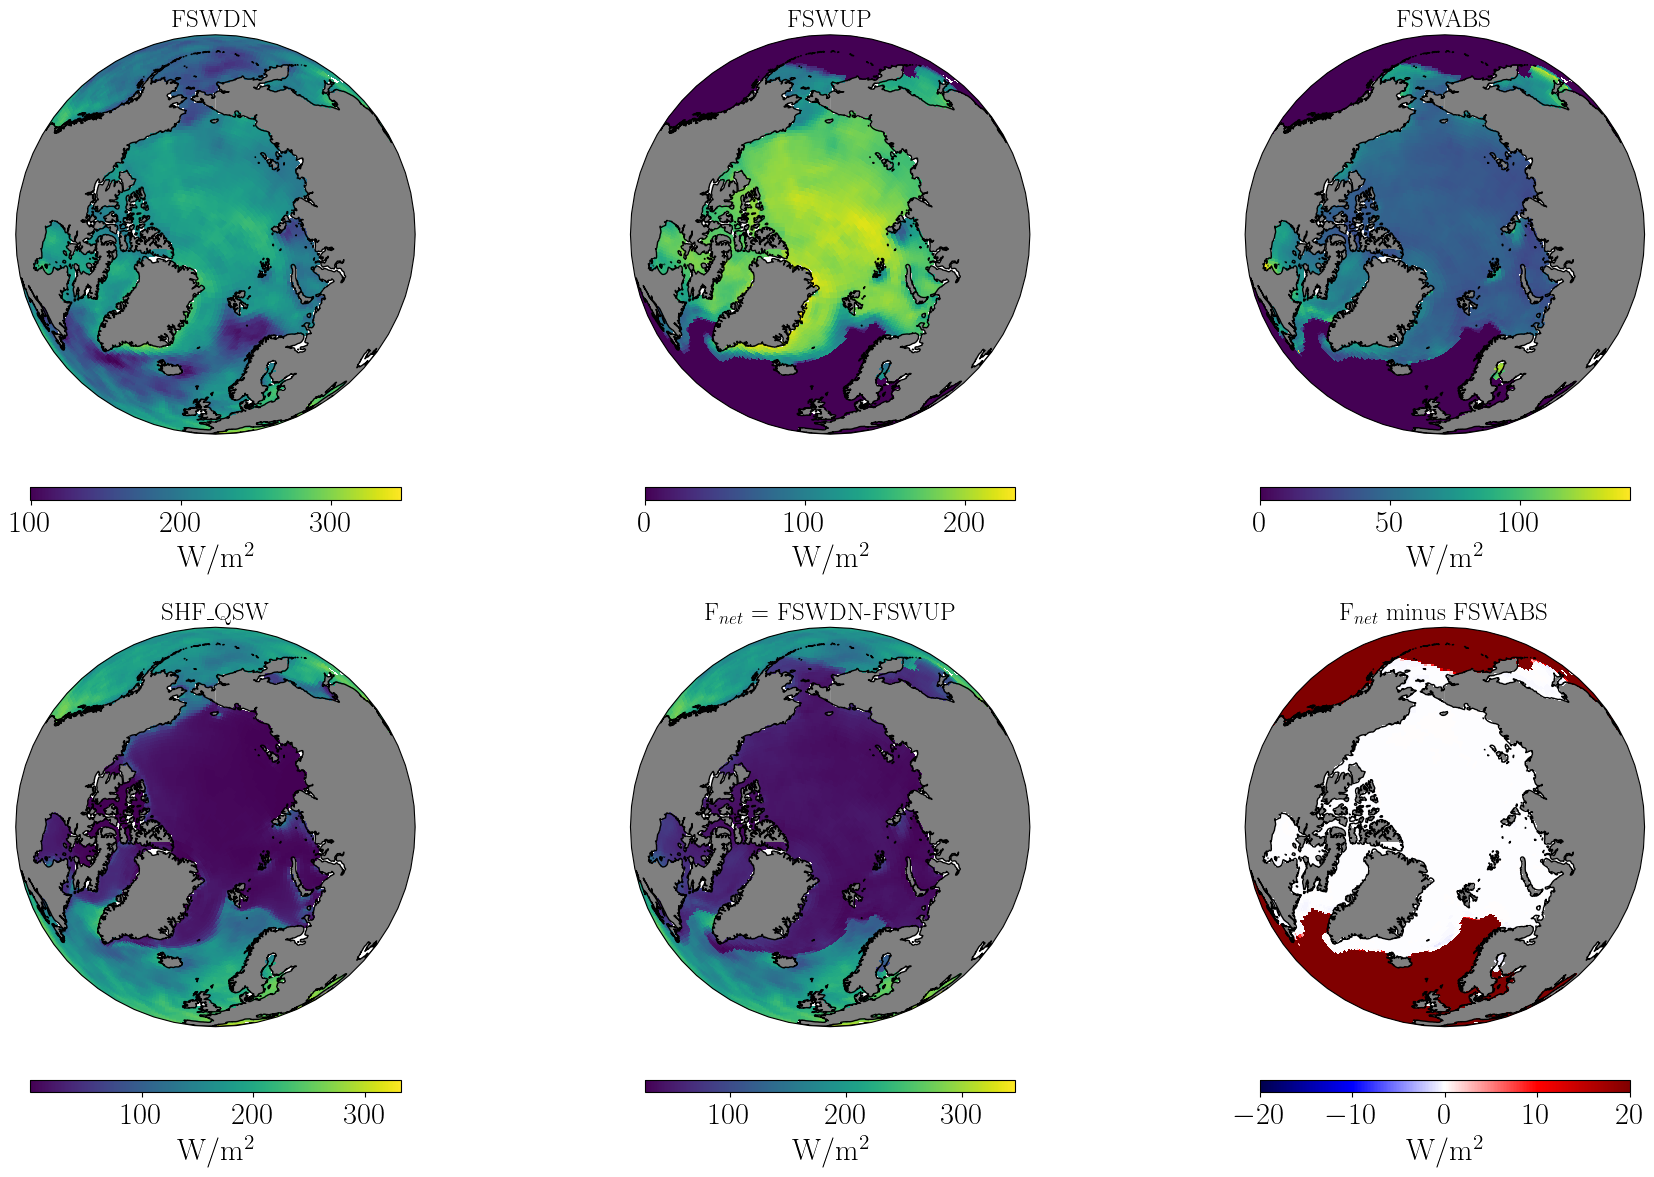

In [33]:

# # Define projection
# proj = ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)

# Define figure and axes
fig, ax = plt.subplots(ncols=3, nrows=2 ,subplot_kw={'projection': proj}, figsize=(20, 12))
ax = ax.flatten()

# Define mappables for each subplot
mappables = [
    ax[0].pcolormesh(grid.TLONG, grid.TLAT, ds_sw.fswdn.sel(time='1980-05', ensemble=10).squeeze(), transform=ccrs.PlateCarree()),
    ax[1].pcolormesh(grid.TLONG, grid.TLAT, (ds_sw.fswup).sel(time='1980-05', ensemble=10).squeeze(), transform=ccrs.PlateCarree()),
    ax[2].pcolormesh(grid.TLONG, grid.TLAT, ds_sw.fswabs.sel(time='1980-05', ensemble=10).squeeze(), transform=ccrs.PlateCarree()),
    ax[3].pcolormesh(grid.TLONG, grid.TLAT, ds_sw.SHF_QSW.sel(time='1980-05', ensemble=10).squeeze(), transform=ccrs.PlateCarree()),
    ax[4].pcolormesh(grid.TLONG, grid.TLAT, (ds_sw.fswdn - ds_sw.fswup).sel(time='1980-05', ensemble=10).squeeze(), transform=ccrs.PlateCarree()),
    ax[5].pcolormesh(grid.TLONG, grid.TLAT, (ds_sw.fswdn - ds_sw.fswup - (ds_sw.fswabs)).sel(time='1980-05', ensemble=10).squeeze(), 
                                                     cmap = 'seismic',vmin=-20, vmax=20,transform=ccrs.PlateCarree())
]

# Customize each subplot
for i in range(6):
    ax[i].coastlines()
    ax[i].add_feature(cfeature.LAND, facecolor='grey')

    # Add individual colorbar
    cbar = fig.colorbar(mappables[i], ax=ax[i], shrink=0.5, aspect=30, pad=0.1, orientation='horizontal')
    cbar.ax.set_xlabel('W/m$^2$', fontsize=22)
    cbar.ax.xaxis.set_label_position('bottom')
    cbar.ax.tick_params(labelsize=22)  

# Set titles
titles = ['FSWDN', 'FSWUP', 'FSWABS', 'SHF_QSW', 'F$_{net}$ = FSWDN-FSWUP', 'F$_{net}$ minus FSWABS']
for i in range(6):
    ax[i].set_title(titles[i], fontsize=18)

fig.tight_layout()
# Save the figure
# plt.savefig('figs/surface_sw_budget_terms.png', format='png', bbox_inches='tight', dpi=300)


### Understanding SHF_QSW over open ocean

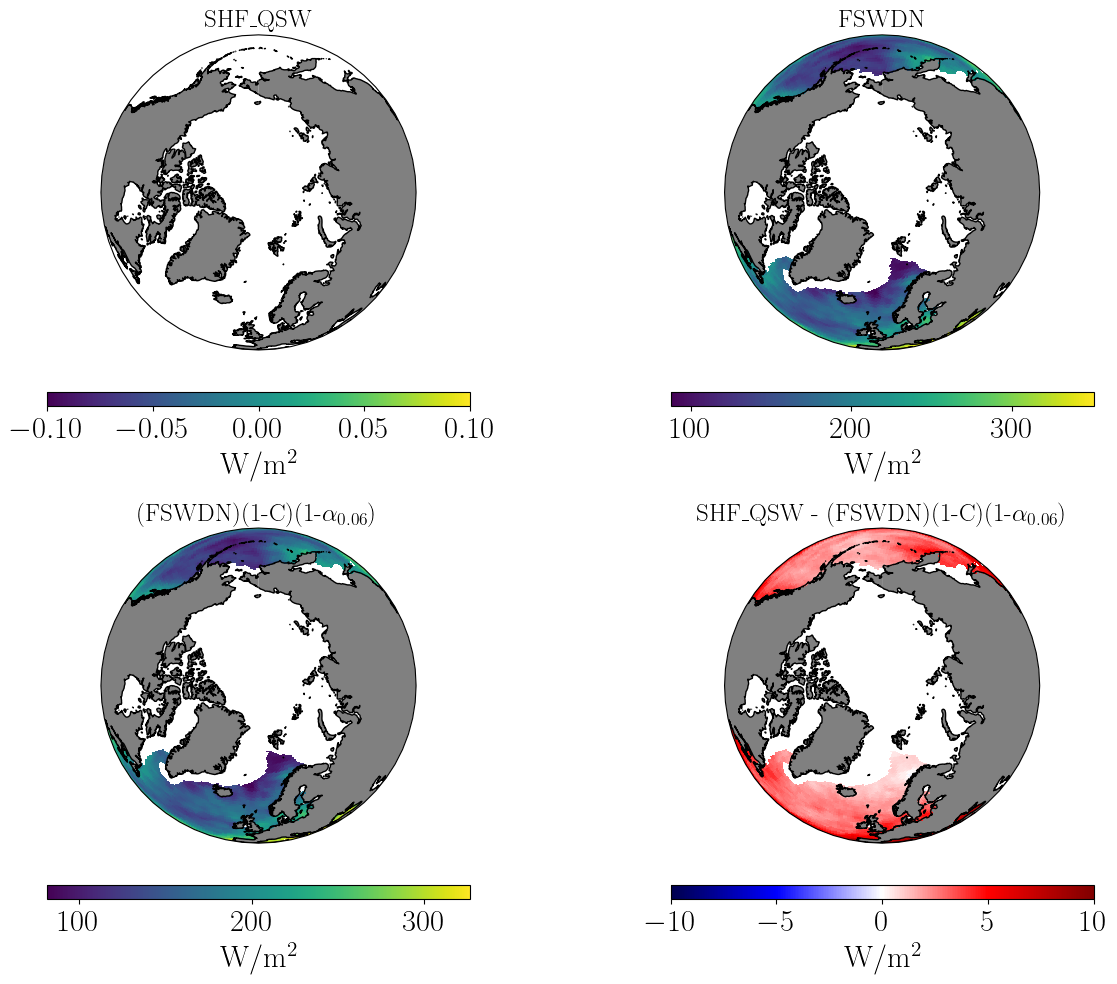

In [34]:

# # Define projection
proj = ccrs.NearsidePerspective(central_longitude=0.0, central_latitude=90.0, satellite_height=5000000)

# Define figure and axes
fig, ax = plt.subplots(ncols=2, nrows=2 ,subplot_kw={'projection': proj}, figsize=(15, 10))
ax = ax.flatten()

diff = (ds_sw.SHF_QSW*(1-ds_sw.aice) - (ds_sw.fswdn*(1-ds_sw.aice)*0.93))
# Define mappables for each subplot
mappables = [
    ax[0].pcolormesh(grid.TLONG, grid.TLAT, ds_sw.SHF_QSW.where(ds_sw.aice<0).sel(time='1980-07', ensemble=10).squeeze(), transform=ccrs.PlateCarree()),
    ax[1].pcolormesh(grid.TLONG, grid.TLAT, (ds_sw.fswdn.where(ds_sw.aice==0)).sel(time='1980-07', ensemble=10).squeeze(), transform=ccrs.PlateCarree()),
    ax[2].pcolormesh(grid.TLONG, grid.TLAT, ((ds_sw.fswdn.where(ds_sw.aice==0))*(1-ds_sw.aice)*0.93).sel(time='1980-07', ensemble=10).squeeze(), transform=ccrs.PlateCarree()),
    ax[3].pcolormesh(grid.TLONG, grid.TLAT, diff.where(ds_sw.aice==0).sel(time='1980-07', ensemble=10).squeeze(),
                                                                                                             vmin=-10, vmax=10, cmap='seismic',transform=ccrs.PlateCarree())
]

# Customize each subplot
for i in range(4):
    ax[i].coastlines()
    ax[i].add_feature(cfeature.LAND, facecolor='grey')

    # Add individual colorbar
    cbar = fig.colorbar(mappables[i], ax=ax[i], shrink=0.5, aspect=30, pad=0.1, orientation='horizontal')
    cbar.ax.set_xlabel('W/m$^2$', fontsize=22)
    cbar.ax.xaxis.set_label_position('bottom')
    cbar.ax.tick_params(labelsize=22)  

# Set titles
titles = ['SHF_QSW', 'FSWDN', r'(FSWDN)(1-C)(1-$\alpha_{0.06}$)', r'SHF_QSW - (FSWDN)(1-C)(1-$\alpha_{0.06}$)']
for i in range(4):
    ax[i].set_title(titles[i], fontsize=18)

fig.tight_layout()
# Save the figure
# plt.savefig('figs/surface_sw_budget_terms.png', format='png', bbox_inches='tight', dpi=300)
